In [1]:
import pandas as pd
import numpy as np 
import os

In [2]:

file_paths = [
    "dataset1.csv",
    "dataset2.csv",
    "dataset3.csv",
    "dataset4.csv"
]

# Load all datasets into dataframes
dfs = [pd.read_csv(fp) for fp in file_paths]

# Combine into one DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Display the first few rows
print("Combined Dataset Preview:")
print(combined_df.head())

# Check for null values in each column
print("\nNull Values in Each Column:")
print(combined_df.isnull().sum())




Combined Dataset Preview:
    cow        date  hour  IN_ALLEYS      REST       EAT  ACTIVITY_LEVEL  \
0  6601  2018-10-25    11   1603.585  1355.386    41.024       -37.93510   
1  6601  2018-10-25    12   1586.965   138.501  1874.528      1009.36093   
2  6601  2018-10-25    13   1442.930   567.066  1584.866       766.08734   
3  6601  2018-10-25    14    209.571  2728.410   662.013      -315.95748   
4  6601  2018-10-25    15   1094.275   298.497  2207.222      1033.46293   

   oestrus  calving  lameness  mastitis  LPS  acidosis  other_disease  \
0        0        0         0         0  0.0       NaN              0   
1        0        0         0         0  0.0       NaN              0   
2        0        0         0         0  0.0       NaN              0   
3        0        0         0         0  0.0       NaN              0   
4        0        0         0         0  0.0       NaN              0   

   accidents  disturbance  mixing  management_changes  OK  
0          0      

In [4]:
# Dropping 'acidosis' and 'LPS' columns
combined_df.drop(columns=['acidosis', 'LPS'], inplace=True)

#  unique values
columns_to_check = [
    'mastitis', 'calving', 'OK', 'management_changes',
    'accidents', 'other_disease', 'oestrus', 'lameness', 'disturbance'
]

# Print unique values for each of these columns
for col in columns_to_check:
    unique_vals = combined_df[col].unique()
    print(f"Unique values in '{col}': {unique_vals}")


Unique values in 'mastitis': [0 1]
Unique values in 'calving': [0 1]
Unique values in 'OK': [1 0]
Unique values in 'management_changes': [0 1]
Unique values in 'accidents': [0 1]
Unique values in 'other_disease': [0 1]
Unique values in 'oestrus': [0 1]
Unique values in 'lameness': [0 1]
Unique values in 'disturbance': [0 1]


In [7]:
print(combined_df.isnull().sum())

cow                   0
date                  0
hour                  0
IN_ALLEYS             0
REST                  0
EAT                   0
ACTIVITY_LEVEL        0
oestrus               0
calving               0
lameness              0
mastitis              0
other_disease         0
accidents             0
disturbance           0
mixing                0
management_changes    0
OK                    0
dtype: int64


In [9]:
combined_df.drop(columns=['management_changes', 'OK'], inplace=True)

In [11]:
combined_df.head()

,cow,date,hour,IN_ALLEYS,REST,EAT,ACTIVITY_LEVEL,oestrus,calving,lameness,mastitis,other_disease,accidents,disturbance,mixing
0,6601,2018-10-25,11,1603.585,1355.386,41.024,-37.93510,0,0,0,0,0,0,0,0
1,6601,2018-10-25,12,1586.965,138.501,1874.528,1009.36093,0,0,0,0,0,0,0,0
2,6601,2018-10-25,13,1442.930,567.066,1584.866,766.08734,0,0,0,0,0,0,0,0
3,6601,2018-10-25,14,209.571,2728.410,662.013,-315.95748,0,0,0,0,0,0,0,0
4,6601,2018-10-25,15,1094.275,298.497,2207.222,1033.46293,0,0,0,0,0,0,0,0


In [13]:
print(combined_df["cow"].unique())

[ 6601  6610  6612  6613  6621  6629  6633  6634  6637  6638  6643  6646
  6656  6664  6674  6675  6683  6686  6689  6690  6693  6695  6699  6701
  6714  6721  6750  7600  7163  8200  8605  8677  9195   151   153   156
   162   173   189  1177  1624  2152  2155  2158  2162  2164  2165  2170
  2175  2179  2182  2183  2185  2187  2603  2622 10127 10567  1565  1797
  1919  2284  2340  2395  2399  2576  2581  2699  4102  4262  4279  4372
  4495  4716  5098  5104  5128  5394  5541  5810  5896  8595  9481  9502
  9601  9994 35687 42599 44432 45683 46649 47875 47899 48094 48133 48599
 48589 48642 48492 48500 48531 48555 49378 49382 49407 49428 49435 49230
 49149 49108 49097 49653 49688 49697 50278 50249 50377 50351 50398 50408
 50422 50433 50454 50478 50468 50482 50493 50508 50577 50603 50627 50649
 50514 50590 50615 50653 50678 50685 50738 50783 50759 50794 50802 53860
 53884 53891 53916 53923 53930 53961 53978 53985 53992 54003 54027 54034
 54065 54089 66242 66259 72650 72667 72681 72698 72

In [15]:
print("Number of rows in the dataset:", combined_df.shape[0])


Number of rows in the dataset: 2351345


In [17]:
# categorizing column cow
combined_df['cow'] = combined_df['cow'].astype(str)

# Converting  'date' to datetime
combined_df['date'] = pd.to_datetime(combined_df['date'], dayfirst=True)

# checking  final structure
print(combined_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351345 entries, 0 to 2351344
Data columns (total 15 columns):
 #   Column          Dtype         
---  ------          -----         
 0   cow             object        
 1   date            datetime64[ns]
 2   hour            int64         
 3   IN_ALLEYS       float64       
 4   REST            float64       
 5   EAT             float64       
 6   ACTIVITY_LEVEL  float64       
 7   oestrus         int64         
 8   calving         int64         
 9   lameness        int64         
 10  mastitis        int64         
 11  other_disease   int64         
 12  accidents       int64         
 13  disturbance     int64         
 14  mixing          int64         
dtypes: datetime64[ns](1), float64(4), int64(9), object(1)
memory usage: 269.1+ MB
None


C:\Users\vishn\AppData\Local\Temp\ipykernel_22564\2470613509.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  combined_df['date'] = pd.to_datetime(combined_df['date'], dayfirst=True)


In [19]:
# Summary statistics
combined_df.describe()




,date,hour,IN_ALLEYS,REST,EAT,ACTIVITY_LEVEL,oestrus,calving,lameness,mastitis,other_disease,accidents,disturbance,mixing
count,2351345,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06,2.351345e+06
mean,2015-08-11 16:41:30.742617600,1.245405e+01,6.447793e+02,2.047169e+03,9.042041e+02,1.208151e+01,3.378492e-03,1.827039e-03,1.367728e-03,4.491047e-04,8.573816e-04,1.531039e-04,1.333543e-01,7.348985e-04
min,2013-10-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.280000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015-03-15 00:00:00,6.000000e+00,9.221300e+01,6.520760e+02,0.000000e+00,-7.612482e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015-06-26 00:00:00,1.200000e+01,3.793600e+02,2.343194e+03,2.424050e+02,-2.191606e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2015-10-09 00:00:00,1.800000e+01,9.238000e+02,3.431997e+03,1.701705e+03,7.124509e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2019-04-17 00:00:00,2.400000e+01,3.600000e+03,3.600000e+03,3.600000e+03,1.512000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,6.925036e+00,7.458313e+02,1.369407e+03,1.126433e+03,7.952105e+02,5.802654e-02,4.270483e-02,3.695751e-02,2.118733e-02,2.926853e-02,1.237257e-02,3.399573e-01,2.709905e-02


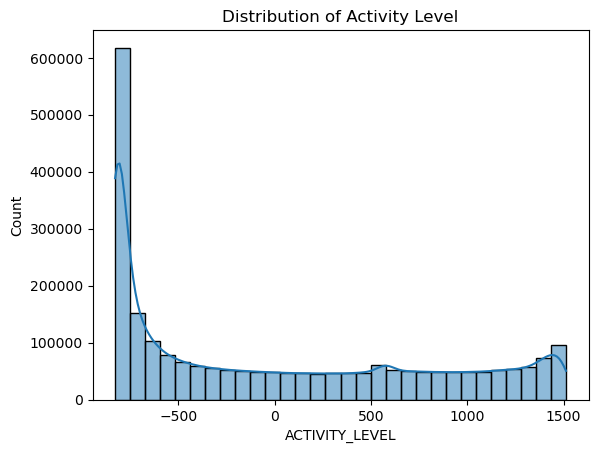

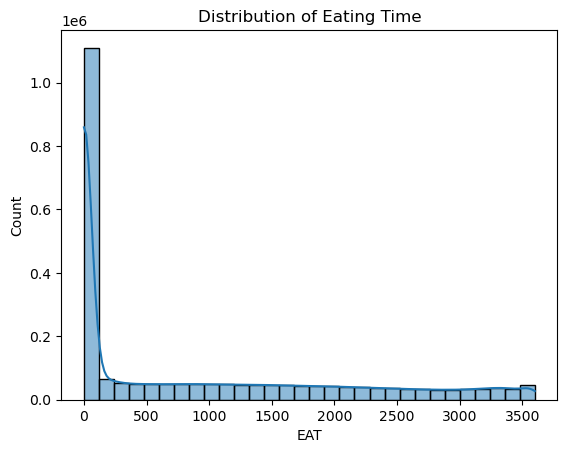

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of activity level
sns.histplot(data=combined_df, x='ACTIVITY_LEVEL', bins=30, kde=True)
plt.title('Distribution of Activity Level')
plt.show()

# Distribution of eating time
sns.histplot(data=combined_df, x='EAT', bins=30, kde=True)
plt.title('Distribution of Eating Time')
plt.show()


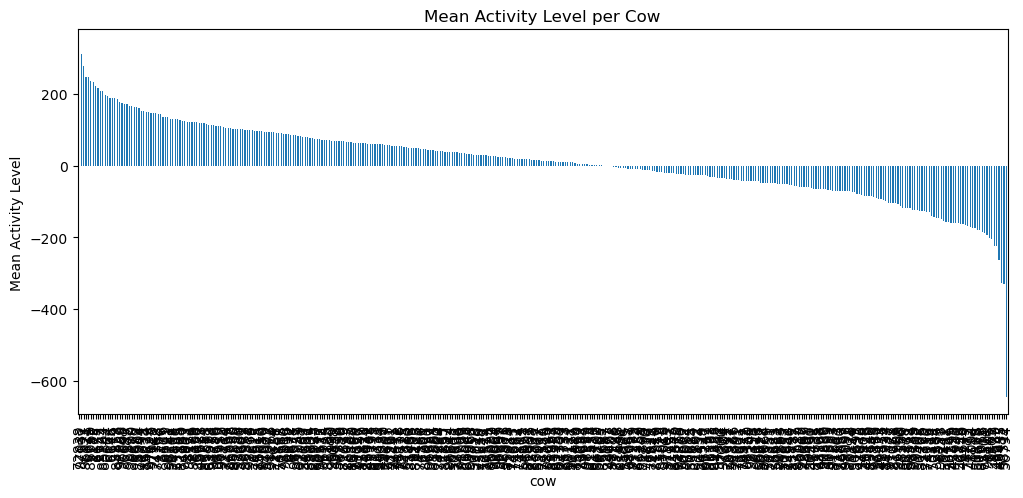

In [12]:
# Mean activity level per cow
activity_per_cow = combined_df.groupby('cow')['ACTIVITY_LEVEL'].mean().sort_values(ascending=False)
activity_per_cow.plot(kind='bar', figsize=(12, 5), title='Mean Activity Level per Cow')
plt.ylabel('Mean Activity Level')
plt.show()


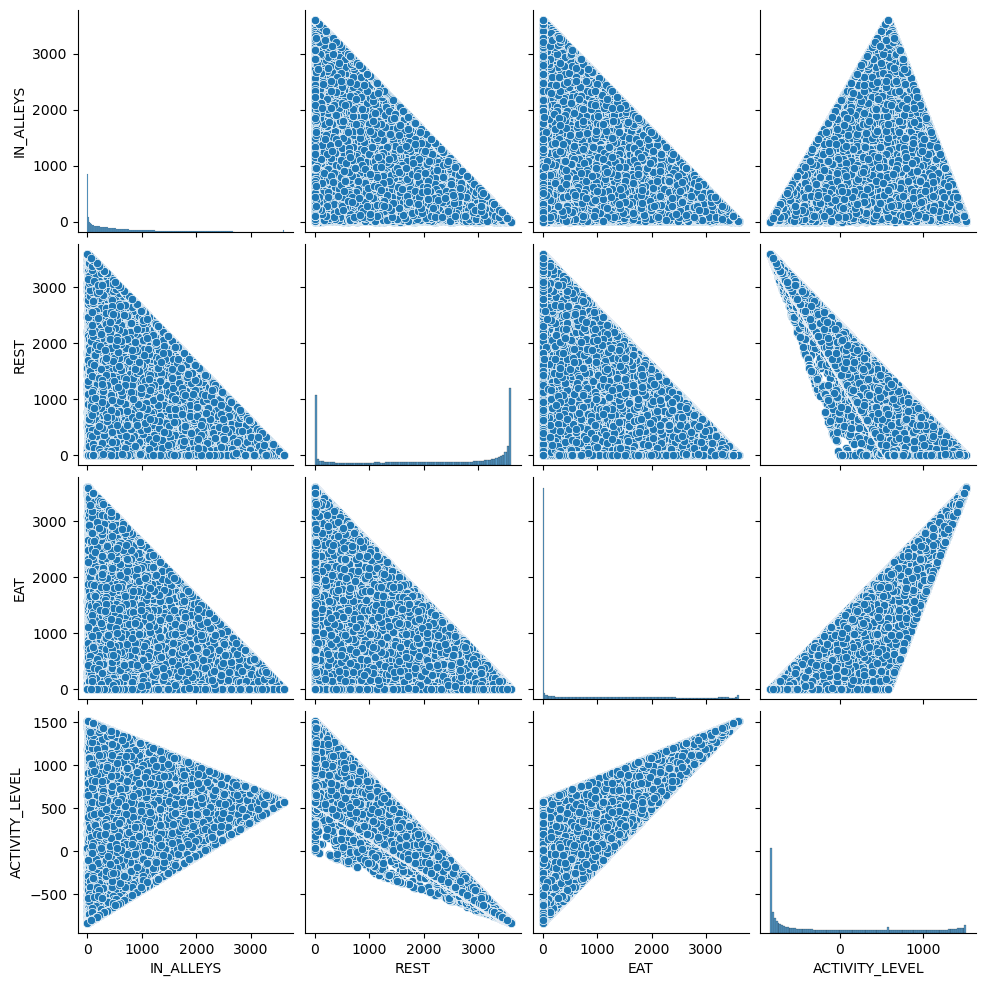

In [13]:
# Pairplot for numeric behavior variables
sns.pairplot(combined_df[['IN_ALLEYS', 'REST', 'EAT', 'ACTIVITY_LEVEL']])
plt.show()


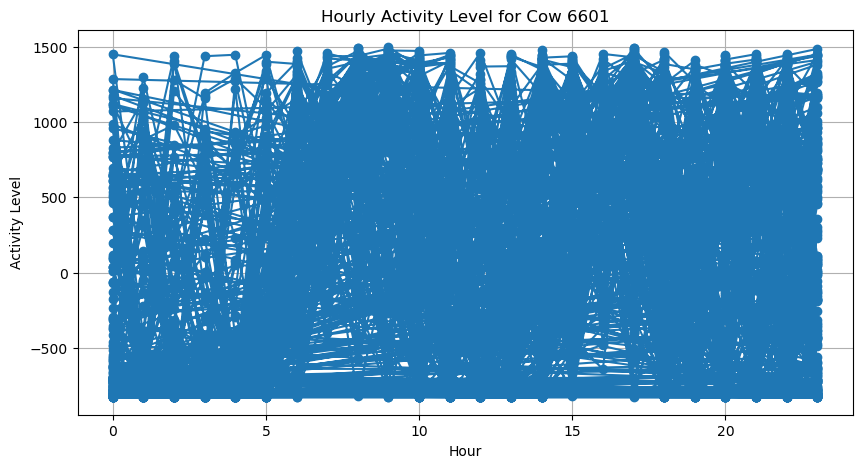

In [14]:
# Trend of activity for cow 6601
cow_id = '6601'
subset = combined_df[combined_df['cow'] == cow_id]

plt.figure(figsize=(10,5))
plt.plot(subset['hour'], subset['ACTIVITY_LEVEL'], marker='o')
plt.title(f'Hourly Activity Level for Cow {cow_id}')
plt.xlabel('Hour')
plt.ylabel('Activity Level')
plt.grid(True)
plt.show()


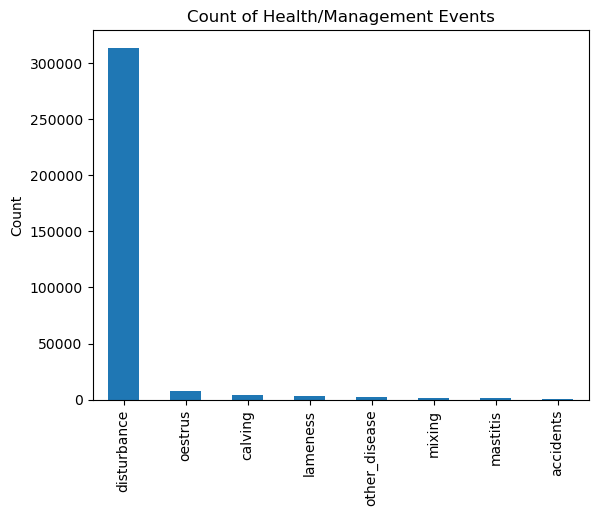

In [15]:
# Sum of binary event columns
event_columns = ['oestrus', 'calving', 'lameness', 'mastitis', 'other_disease', 'accidents', 'disturbance', 'mixing']
event_counts = combined_df[event_columns].sum().sort_values(ascending=False)

event_counts.plot(kind='bar', title='Count of Health/Management Events')
plt.ylabel('Count')
plt.show()


In [16]:
combined_df.shape

(2351345, 15)

In [17]:
disease_columns = [
    "oestrus", "calving", "lameness", "mastitis", "other_disease",
    "accidents", "disturbance", "mixing"
]

# Count of 0s and 1s in each disease column
disease_counts = combined_df[disease_columns].apply(lambda col: col.value_counts()).T

# Rename columns for clarity
disease_counts.columns = ["Count of 0s", "Count of 1s"]


# Display the result
print(disease_counts)

               Count of 0s  Count of 1s
oestrus            2343401         7944
calving            2347049         4296
lameness           2348129         3216
mastitis           2350289         1056
other_disease      2349329         2016
accidents          2350985          360
disturbance        2037783       313562
mixing             2349617         1728


In [23]:
combined_df.to_csv("clean_stage1.csv")